# Classification using Tensorflow

In [2]:
import tensorflow as tf

In [3]:
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples, noise=0.03, random_state=42)

import pandas as pd
circles = pd.DataFrame({"X0": X[:, 0], "X1": X[:, 1], "label": y})

circles

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


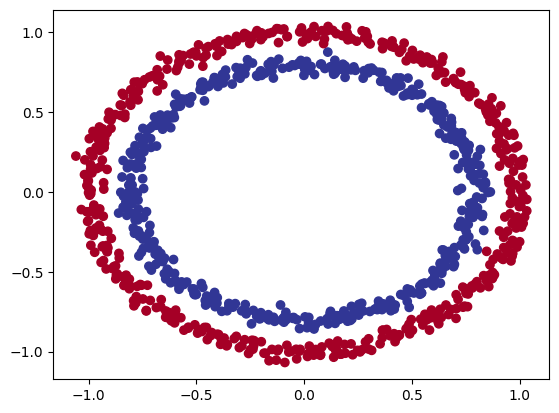

In [4]:
from matplotlib.colors import Colormap
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [5]:
## Building a Model
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

history = model.fit(X, y, epochs=100, verbose=0)

In [6]:
# Creating Model 1 Traning for longer
model.fit(X, y, epochs=200, verbose=0)
model.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4790 - loss: 0.6932 


[0.6932169198989868, 0.4790000021457672]

In [7]:
tf.random.set_seed(42)

model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

history_1 = model_1.fit(X, y, epochs=100, verbose=0)
model_1.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4850 - loss: 0.6943  


[0.694294810295105, 0.48500001430511475]

In [8]:
tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1)
])

model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=['accuracy'])

history_2 = model_2.fit(X, y, epochs=100, verbose=0)
model_2.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0048      


[0.004828749690204859, 1.0]

In [9]:
# Function to visualize the decision boundary of a trained model
def plot_decision_boundary(model, X, y):
  import numpy as np
  import matplotlib.pyplot as plt
  import tensorflow as tf # Import tensorflow for tf.squeeze if not already imported globally

  # Define the axis boundaries of the plot based on the input data X
  # We add a small margin (0.1) to ensure all data points are visible.
  x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
  y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

  # Create a meshgrid: This generates a grid of points (xx, yy) over the entire plot area.
  # The model will make predictions for each of these points to draw the decision boundary.
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                      np.linspace(y_min, y_max, 100))

  # Prepare input for the model: This converts the 2D grid points into a flat array of (x, y) coordinates.
  # Fix 1: The original code `np.c_[[xx.ravel(), yy.ravel()]]` created a shape (2, 10000)
  # (2 samples, 10000 features each). The model expects (number_of_samples, number_of_features),
  # so it should be (10000, 2). Removing the outer list `[]` corrects this.
  x_in = np.c_[xx.ravel(), yy.ravel()]

  # Make predictions on the grid points using the provided model.
  y_pred = model.predict(x_in)

  # Process predictions to get class labels and reshape them back to the grid shape.
  # This is crucial for plotting the decision regions.
  if y_pred.shape[-1] == 1: # This condition typically indicates binary classification (single output neuron)
    # For binary classification, model.predict often outputs probabilities (e.g., between 0 and 1).
    # We convert these probabilities to class labels (0 or 1) by applying a threshold (e.g., 0.5).
    # tf.squeeze removes single-dimensional entries from the shape of an array.
    p_pred = (tf.squeeze(y_pred) > 0.5).numpy().reshape(xx.shape)
  else: # This condition handles multi-class classification (multiple output neurons with softmax)
    # In multi-class, we take the index of the highest probability as the predicted class.
    print("doing multiclass classification") # Original print statement kept for context
    p_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)

  # Plot the decision boundary.
  # Fix 2: Typo - `plt.countourf` should be `plt.contourf`.
  # Fix 3: The third argument to `contourf` should be `p_pred` (the model's predictions on the grid),
  # not `y` (the original true labels). Plotting `y` would show contours based on the original data distribution,
  # not the model's learned decision regions.
  plt.contourf(xx, yy, p_pred, cmap=plt.cm.RdYlBu, alpha=0.7)

  # Plot the original data points on top of the decision boundary.
  # `c=y` colors the points according to their true labels.
  plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)

  # Set plot limits to match the meshgrid boundaries.
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())

  # Display the plot.
  plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step


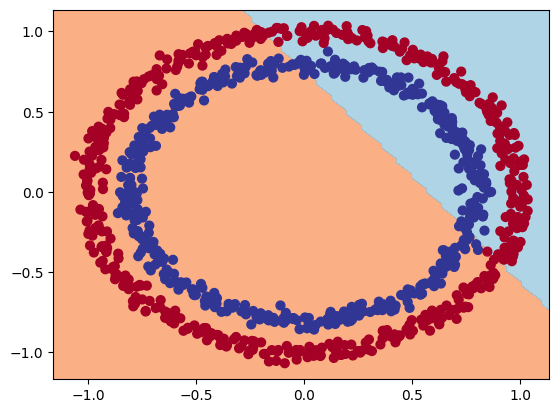

In [10]:
plot_decision_boundary(model, X, y)

## Introduction to non-linearity


In [11]:
tf.random.set_seed(42)

model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.linear),
])

model_4.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

history_4 = model_4.fit(X, y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4870 - loss: 6.4938   
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4860 - loss: 6.4563 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4850 - loss: 6.4519 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4860 - loss: 6.4362 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4880 - loss: 6.4300 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4890 - loss: 6.4292 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4900 - loss: 6.4287 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4900 - loss: 6.4282 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4900 - loss: 6.4278 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4900 - loss: 6.4275 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4890 - loss: 6.4272
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 705us/step


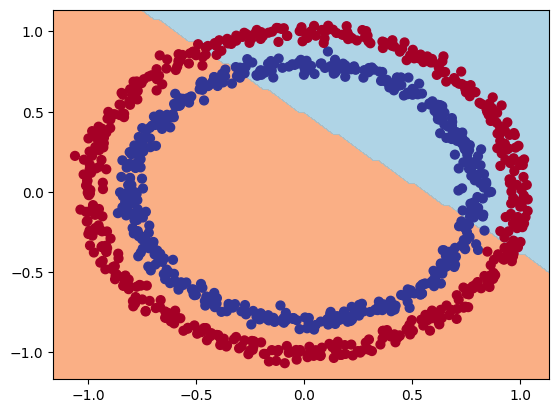

In [12]:
plot_decision_boundary(model_4, X, y)

In [13]:
tf.random.set_seed(42)

model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.relu)
])

model_5.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

history_5 = model_5.fit(X, y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.4770 - loss: 5.3339
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4780 - loss: 5.1868   
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4800 - loss: 4.9666 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4760 - loss: 4.8330 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4770 - loss: 4.7276 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4750 - loss: 4.6989 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4730 - loss: 4.6873 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4710 - loss: 4.6788 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4710 - loss: 4.6717 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4710 - loss: 4.6656 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4710 - loss: 4.6601 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/ste

In [14]:
model_5.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4550 - loss: 0.7627  


[0.7626935839653015, 0.45500001311302185]

In [15]:
tf.random.set_seed(42)

model_6 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(1)
])


model_6.compile(loss='binary_crossentropy',
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=['accuracy'])

history_6 = model_6.fit(X, y, epochs=200, verbose=0)

The important of activation in the output layer? and also in other layers? and what are the activations to use?

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9430 - loss: 0.2404  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step


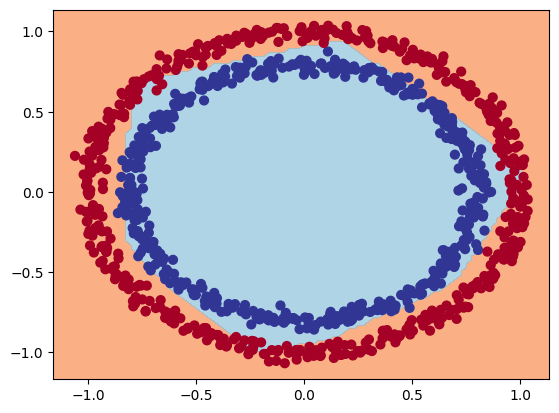

In [16]:
model_6.evaluate(X, y)

plot_decision_boundary(model_6, X, y)

In [17]:
tf.random.set_seed(42)

model_7 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(1, activation=tf.keras.activations.sigmoid)
])

model_7.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=['accuracy']) # Changed tf.keras.metrics.Accuracy() to 'accuracy'

history_7 = model_7.fit(X, y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4990 - loss: 0.6948   
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5010 - loss: 0.6940 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5020 - loss: 0.6931 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4970 - loss: 0.6922 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5090 - loss: 0.6914 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5100 - loss: 0.6906 
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5140 - loss: 0.6900 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5200 - loss: 0.6893 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5150 - loss: 0.6887 
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5090 - loss: 0.6881 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5100 - loss: 0.6875 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/ste

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7630 - loss: 0.4705  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 947us/step


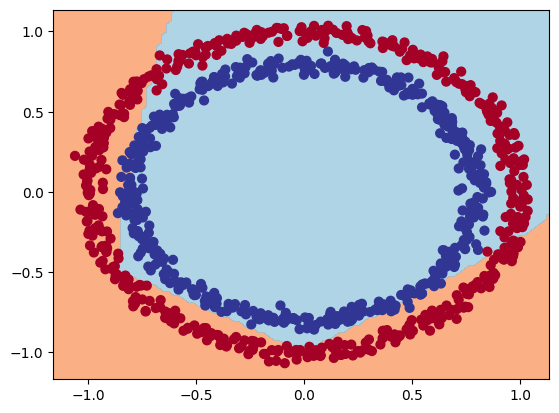

In [18]:
model_7.evaluate(X, y)

plot_decision_boundary(model_7, X, y)

The combination of linear and non-linear functions is one of the key fundamentals of neural network. IN the Relu and Sigmoid note, transform a normal tensor vector into relu and plot?

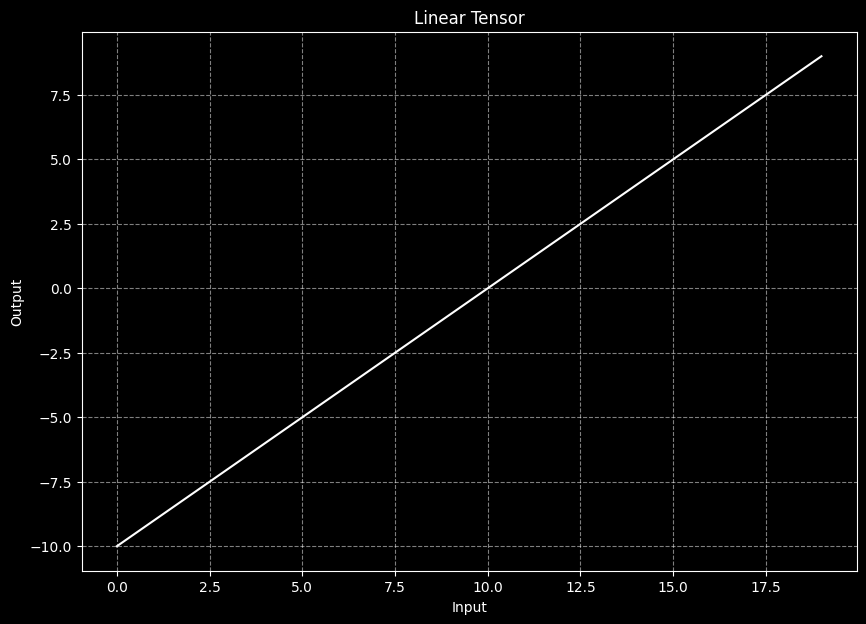

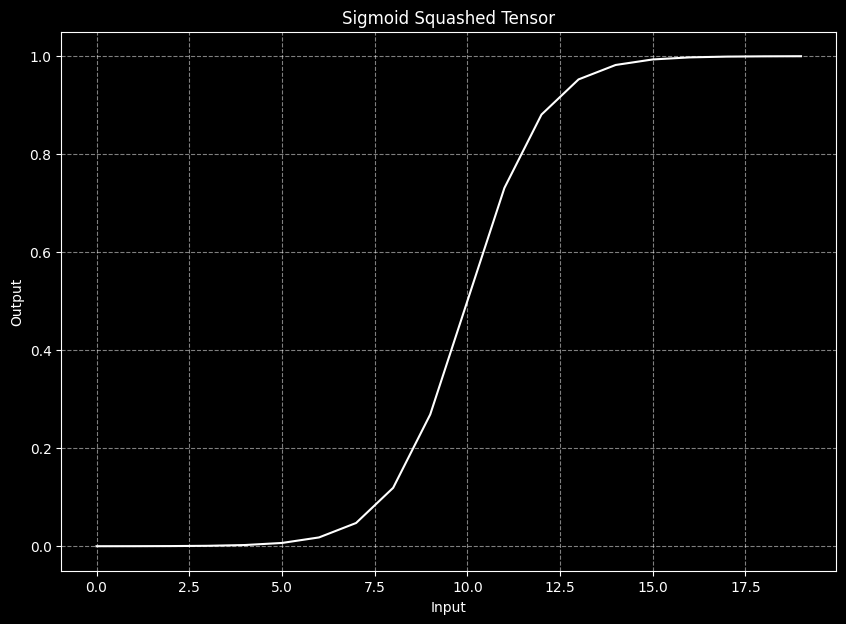

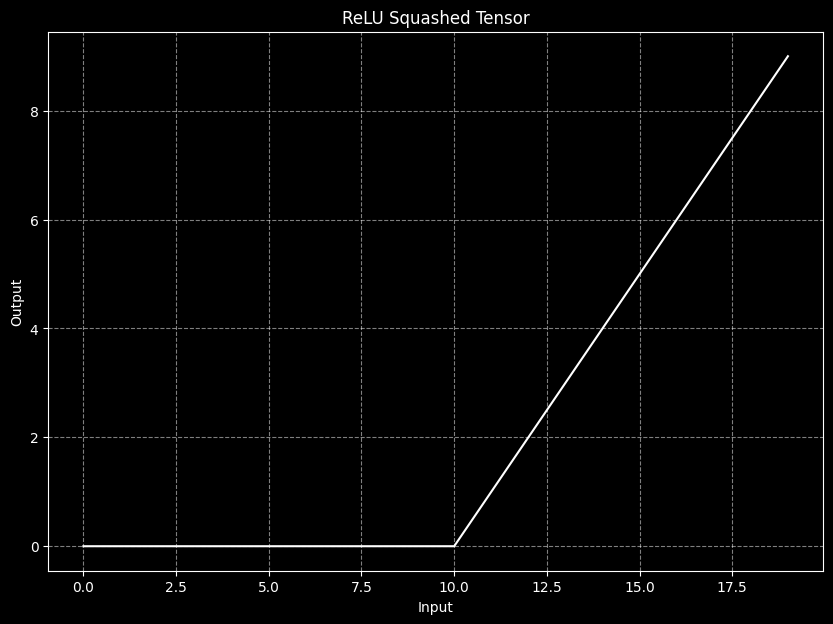

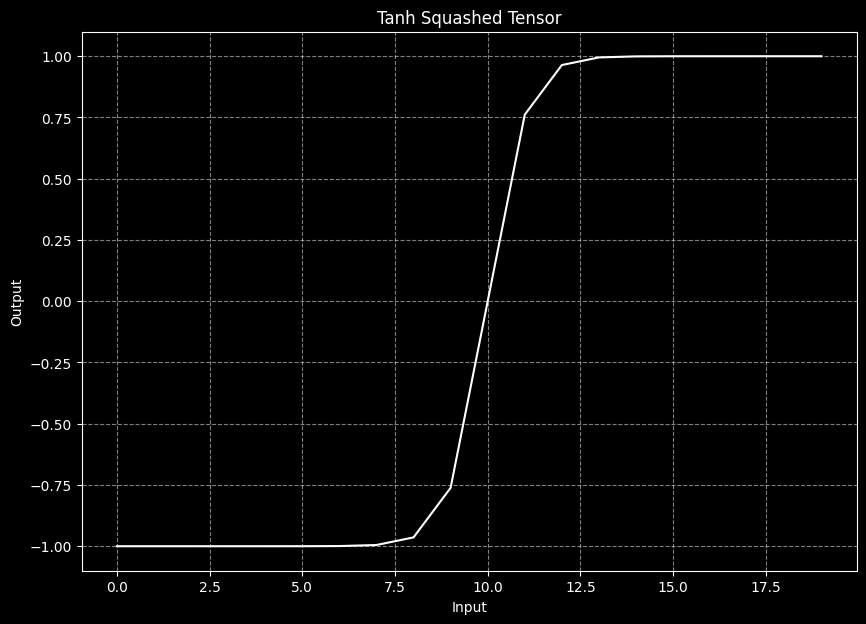

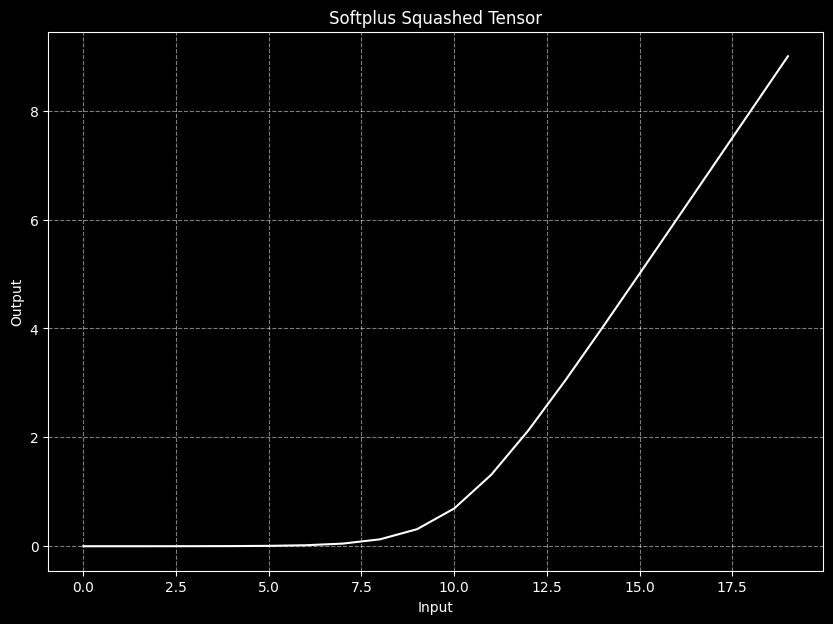

In [19]:
import matplotlib.pyplot as plt
import tensorflow as tf # Ensure tf is imported for activation functions

linear_line = tf.cast(tf.range(-10, 10), tf.float32)

# Plot Linear Tensor
fig_linear = plt.figure(figsize=(10, 7), facecolor='black')
ax_linear = fig_linear.add_subplot(111)
ax_linear.set_facecolor('black') # Set axes background to black
ax_linear.plot(linear_line, color='white')
ax_linear.set_title("Linear Tensor", color='white')
ax_linear.set_xlabel("Input", color='white')
ax_linear.set_ylabel("Output", color='white')
ax_linear.tick_params(axis='x', colors='white')
ax_linear.tick_params(axis='y', colors='white')
ax_linear.spines['bottom'].set_color('white') # Set x-axis line color
ax_linear.spines['top'].set_color('white')    # Set top spine color
ax_linear.spines['left'].set_color('white')   # Set y-axis line color
ax_linear.spines['right'].set_color('white')  # Set right spine color
ax_linear.grid(True, color='white', linestyle='--', alpha=0.5) # Add white grid
plt.savefig("linear.png", facecolor='black') # Save with black background
plt.show()
plt.close(fig_linear) # Close the figure to ensure separate display and free memory

# Create a sigmoid squashing of the tensor
sigmoid = tf.math.sigmoid(linear_line)
fig_sigmoid = plt.figure(figsize=(10, 7), facecolor='black')
ax_sigmoid = fig_sigmoid.add_subplot(111)
ax_sigmoid.set_facecolor('black')
ax_sigmoid.plot(sigmoid, color='white')
ax_sigmoid.set_title("Sigmoid Squashed Tensor", color='white')
ax_sigmoid.set_xlabel("Input", color='white')
ax_sigmoid.set_ylabel("Output", color='white')
ax_sigmoid.tick_params(axis='x', colors='white')
ax_sigmoid.tick_params(axis='y', colors='white')
ax_sigmoid.spines['bottom'].set_color('white')
ax_sigmoid.spines['top'].set_color('white')
ax_sigmoid.spines['left'].set_color('white')
ax_sigmoid.spines['right'].set_color('white')
ax_sigmoid.grid(True, color='white', linestyle='--', alpha=0.5)
plt.savefig("sigmoid.png", facecolor='black')
plt.show()
plt.close(fig_sigmoid)

# Create ReLU squashing of the tensor
relu = tf.math.maximum(0, linear_line)
fig_relu = plt.figure(figsize=(10, 7), facecolor='black')
ax_relu = fig_relu.add_subplot(111)
ax_relu.set_facecolor('black')
ax_relu.plot(relu, color='white')
ax_relu.set_title("ReLU Squashed Tensor", color='white')
ax_relu.set_xlabel("Input", color='white')
ax_relu.set_ylabel("Output", color='white')
ax_relu.tick_params(axis='x', colors='white')
ax_relu.tick_params(axis='y', colors='white')
ax_relu.spines['bottom'].set_color('white')
ax_relu.spines['top'].set_color('white')
ax_relu.spines['left'].set_color('white')
ax_relu.spines['right'].set_color('white')
ax_relu.grid(True, color='white', linestyle='--', alpha=0.5)
plt.savefig("relu.png", facecolor='black')
plt.show()
plt.close(fig_relu)

# Create Tanh squashing of the tensor
tanh = tf.math.tanh(linear_line)
fig_tanh = plt.figure(figsize=(10, 7), facecolor='black')
ax_tanh = fig_tanh.add_subplot(111)
ax_tanh.set_facecolor('black')
ax_tanh.plot(tanh, color='white')
ax_tanh.set_title("Tanh Squashed Tensor", color='white')
ax_tanh.set_xlabel("Input", color='white')
ax_tanh.set_ylabel("Output", color='white')
ax_tanh.tick_params(axis='x', colors='white')
ax_tanh.tick_params(axis='y', colors='white')
ax_tanh.spines['bottom'].set_color('white')
ax_tanh.spines['top'].set_color('white')
ax_tanh.spines['left'].set_color('white')
ax_tanh.spines['right'].set_color('white')
ax_tanh.grid(True, color='white', linestyle='--', alpha=0.5)
plt.savefig("tanh.png", facecolor='black')
plt.show()
plt.close(fig_tanh)

# Create Softplus squashing of the tensor
softplus = tf.math.softplus(linear_line)
fig_softplus = plt.figure(figsize=(10, 7), facecolor='black')
ax_softplus = fig_softplus.add_subplot(111)
ax_softplus.set_facecolor('black')
ax_softplus.plot(softplus, color='white')
ax_softplus.set_title("Softplus Squashed Tensor", color='white')
ax_softplus.set_xlabel("Input", color='white')
ax_softplus.set_ylabel("Output", color='white')
ax_softplus.tick_params(axis='x', colors='white')
ax_softplus.tick_params(axis='y', colors='white')
ax_softplus.spines['bottom'].set_color('white')
ax_softplus.spines['top'].set_color('white')
ax_softplus.spines['left'].set_color('white')
ax_softplus.spines['right'].set_color('white')
ax_softplus.grid(True, color='white', linestyle='--', alpha=0.5)
plt.savefig("softplus.png", facecolor='black')
plt.show()
plt.close(fig_softplus)

In [20]:
## Evaluating and improving our classification

len(X)

1000

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((750, 2), (250, 2), (750,), (250,))

What is learning rate and how it actually improves a mdoels learning?

In [34]:
# Training and Testing

tf.random.set_seed(42)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="accuracy",
    patience=10,
    restore_best_weights=True
)

final_model = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(1, activation=tf.keras.activations.sigmoid)
])

final_model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                    metrics=['accuracy'])

final_history = final_model.fit(X_train, y_train, epochs=200, callbacks=[early_stopping])

Epoch 1/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4760 - loss: 0.6945
Epoch 2/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5147 - loss: 0.6917 
Epoch 3/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5360 - loss: 0.6888 
Epoch 4/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5320 - loss: 0.6836 
Epoch 5/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5587 - loss: 0.6755 
Epoch 6/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5707 - loss: 0.6649 
Epoch 7/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6000 - loss: 0.6483 
Epoch 8/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6573 - loss: 0.6235 
Epoch 9/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8067 - loss: 0.5834 
Epoch 10/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9400 - loss: 0.5240 
Epoch 11/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9720 - loss: 0.4504 
Epoch 12/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step -

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9840 - loss: 0.1201  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 899us/step


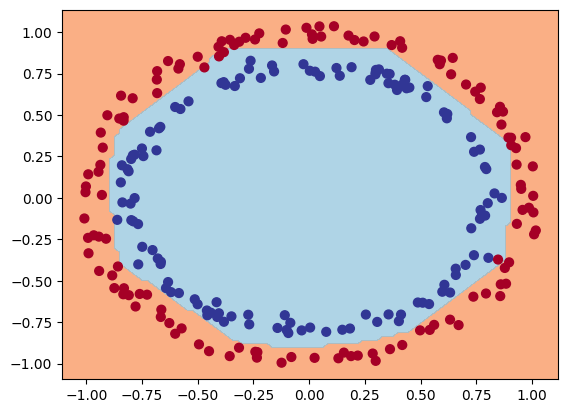

In [35]:
final_model.evaluate(X_test, y_test)
plot_decision_boundary(final_model, X_test, y_test)

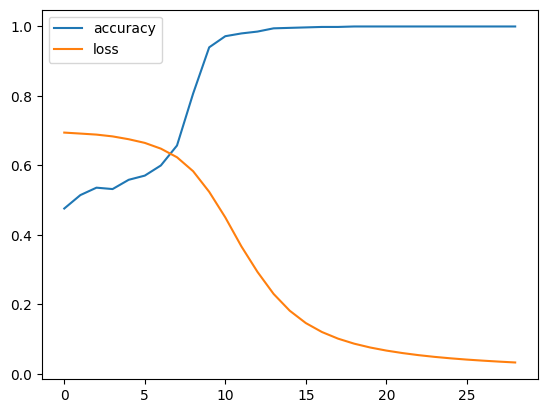

In [36]:
# Printing Loss Curvs
pd.DataFrame(final_history.history).plot()
plt.show()


In [40]:
# Callbacks and learning rate vs loss decrease

tf.random.set_seed(42)

model_9 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_9.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/20))

history_9 = model_9.fit(X_train, y_train, epochs=100, callbacks=[lr_scheduler])


Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5080 - loss: 0.6938 - learning_rate: 1.0000e-04
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5067 - loss: 0.6937 - learning_rate: 1.1220e-04
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5067 - loss: 0.6936 - learning_rate: 1.2589e-04
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5053 - loss: 0.6935 - learning_rate: 1.4125e-04
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5040 - loss: 0.6935 - learning_rate: 1.5849e-04
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5053 - loss: 0.6934 - learning_rate: 1.7783e-04
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5053 - loss: 0.6933 - learning_rate: 1.9953e-04
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5067 - loss: 0.6931 - learning_rate: 2.2387e-04
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5067 - loss: 0.6930 - learning_

<Axes: >

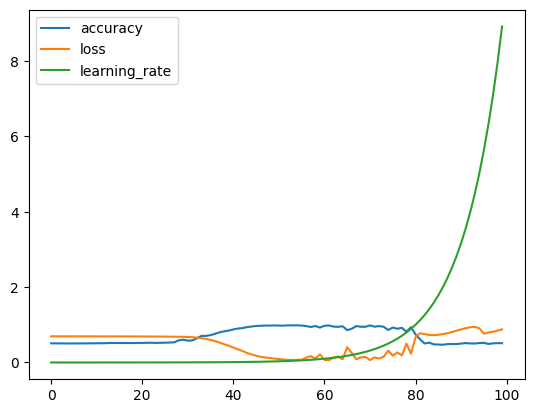

In [41]:
pd.DataFrame(history_9.history).plot()

In [42]:
model_9.evaluate(X_test, y_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5160 - loss: 0.7293  


[0.7293093204498291, 0.515999972820282]

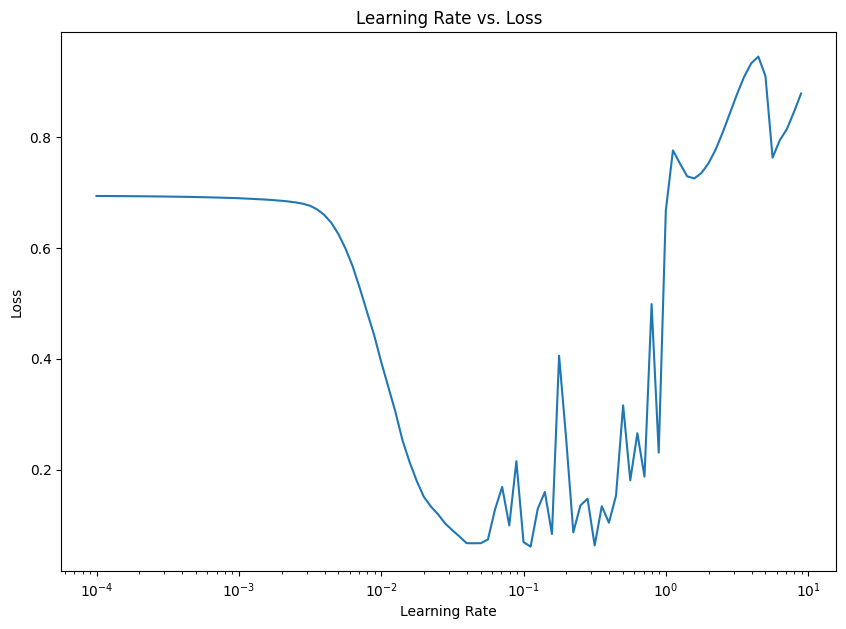

In [43]:
# plot the learning rate versus the loss
lrs = 1e-4 * (10 ** (tf.range(100)/20))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history_9.history["loss"])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning Rate vs. Loss")
plt.show()


Finding the ideal learning rate from the loss curve. The ideal learning rate is when the loss is still decreasing but it hasen't platued.

In [49]:
tf.random.set_seed(42)

model_10 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_10.compile(loss="binary_crossentropy",
                 optimizer=tf.keras.optimizers.Adam(learning_rate=0.02),
                 metrics=["accuracy"])

model_10.fit(X_train, y_train, epochs=40)

Epoch 1/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4573 - loss: 0.7017
Epoch 2/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4987 - loss: 0.6923 
Epoch 3/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5787 - loss: 0.6861 
Epoch 4/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5707 - loss: 0.6703 
Epoch 5/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6227 - loss: 0.6361
Epoch 6/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6800 - loss: 0.5892 
Epoch 7/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7440 - loss: 0.5356 
Epoch 8/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8400 - loss: 0.4561 
Epoch 9/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9640 - loss: 0.3414 
Epoch 10/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9667 - loss: 0.2551 
Epoch 11/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9773 - loss: 0.2052 
Epoch 12/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9760 - loss: 0.0553  
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 864us/step


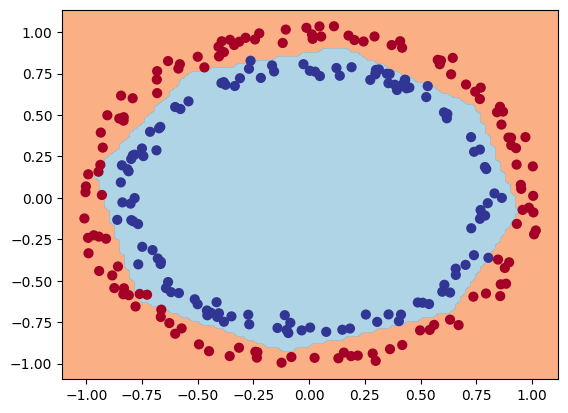

In [50]:
model_10.evaluate(X_test, y_test)
plot_decision_boundary(model_10, X_test, y_test)